# Maps II: Choropleth maps

files needed = ('ne_50m_admin_0_countries', 'cb_2021_us_county_5m', 'elections2024.csv')

We have figured out how to plot geographic data using geopandas. We needed shape files loaded into geoDataFrames with one column assigned as the geoDataFrame's geometry. Once that is set up, plotting is easy. 

In this notebook we are going to learn how to assign colors to maps based on a variable &mdash; a *choropleth*. We looked at an example of this kind of figure on the first day of class: [Voting patterns in Wisconsin](https://www.cnn.com/election/2024/results/wisconsin/president). By the end of this workbook, we will have made a similar map. 

In [1]:
import pandas as pd                         # pandas for data management
import geopandas as gpd                         # geopandas for maps work
import matplotlib.pyplot as plt             # matplotlib for plotting details
import os
os.chdir('/Users/jackson/Documents/ECON570')

## Choropleth maps

A choropleth map is one in which each region is assigned a color based on a variable. 
* 'column' is the column name that holds the variable to color by
* 'cmap' is the color scheme. There are [many](https://matplotlib.org/stable/tutorials/colors/colormaps.html). Review the visualization notebook for a refresher on what types of color map are appropriate for different applications.  

Let's return to the world map from the *maps* notebook.  

In [2]:
import geopandas as gpd
world = gpd.read_file("zip://data/ne_50m_admin_0_countries.zip", engine="fiona")
world.head(2)

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,ADMIN,ADM0_A3,...,NAME_KO,NAME_NL,NAME_PL,NAME_PT,NAME_RU,NAME_SV,NAME_TR,NAME_VI,NAME_ZH,geometry
0,Admin-0 country,1,3,Zimbabwe,ZWE,0,2,Sovereign country,Zimbabwe,ZWE,...,짐바브웨,Zimbabwe,Zimbabwe,Zimbábue,Зимбабве,Zimbabwe,Zimbabve,Zimbabwe,辛巴威,"POLYGON ((31.288 -22.402, 31.197 -22.345, 31.0..."
1,Admin-0 country,1,3,Zambia,ZMB,0,2,Sovereign country,Zambia,ZMB,...,잠비아,Zambia,Zambia,Zâmbia,Замбия,Zambia,Zambiya,Zambia,赞比亚,"POLYGON ((30.396 -15.643, 30.251 -15.643, 29.9..."


In [3]:
list(world.columns)

['featurecla',
 'scalerank',
 'LABELRANK',
 'SOVEREIGNT',
 'SOV_A3',
 'ADM0_DIF',
 'LEVEL',
 'TYPE',
 'ADMIN',
 'ADM0_A3',
 'GEOU_DIF',
 'GEOUNIT',
 'GU_A3',
 'SU_DIF',
 'SUBUNIT',
 'SU_A3',
 'BRK_DIFF',
 'NAME',
 'NAME_LONG',
 'BRK_A3',
 'BRK_NAME',
 'BRK_GROUP',
 'ABBREV',
 'POSTAL',
 'FORMAL_EN',
 'FORMAL_FR',
 'NAME_CIAWF',
 'NOTE_ADM0',
 'NOTE_BRK',
 'NAME_SORT',
 'NAME_ALT',
 'MAPCOLOR7',
 'MAPCOLOR8',
 'MAPCOLOR9',
 'MAPCOLOR13',
 'POP_EST',
 'POP_RANK',
 'GDP_MD_EST',
 'POP_YEAR',
 'LASTCENSUS',
 'GDP_YEAR',
 'ECONOMY',
 'INCOME_GRP',
 'WIKIPEDIA',
 'FIPS_10_',
 'ISO_A2',
 'ISO_A3',
 'ISO_A3_EH',
 'ISO_N3',
 'UN_A3',
 'WB_A2',
 'WB_A3',
 'WOE_ID',
 'WOE_ID_EH',
 'WOE_NOTE',
 'ADM0_A3_IS',
 'ADM0_A3_US',
 'ADM0_A3_UN',
 'ADM0_A3_WB',
 'CONTINENT',
 'REGION_UN',
 'SUBREGION',
 'REGION_WB',
 'NAME_LEN',
 'LONG_LEN',
 'ABBREV_LEN',
 'TINY',
 'HOMEPART',
 'MIN_ZOOM',
 'MIN_LABEL',
 'MAX_LABEL',
 'NE_ID',
 'WIKIDATAID',
 'NAME_AR',
 'NAME_BN',
 'NAME_DE',
 'NAME_EN',
 'NAME_ES',
 'NA

In [4]:
world[world['POP_EST'] < 100000]

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,ADMIN,ADM0_A3,...,NAME_KO,NAME_NL,NAME_PL,NAME_PT,NAME_RU,NAME_SV,NAME_TR,NAME_VI,NAME_ZH,geometry
5,Admin-0 country,6,6,Vatican,VAT,0,2,Sovereign country,Vatican,VAT,...,바티칸 시국,Vaticaanstad,Watykan,Vaticano,Ватикан,Vatikanstaten,Vatikan,Thành Vatican,梵蒂冈,"POLYGON ((12.439 41.898, 12.431 41.898, 12.428..."
10,Admin-0 country,5,6,Marshall Islands,MHL,0,2,Sovereign country,Marshall Islands,MHL,...,마셜 제도,Marshalleilanden,Wyspy Marshalla,Ilhas Marshall,Маршалловы Острова,Marshallöarna,Marshall Adaları,Quần đảo Marshall,馬紹爾群島,"MULTIPOLYGON (((169.64 5.8301, 169.62 5.7998, ..."
11,Admin-0 country,3,6,United States of America,US1,1,2,Dependency,Northern Mariana Islands,MNP,...,북마리아나 제도,Noordelijke Marianen,Mariany Północne,Marianas Setentrionais,Северные Марианские острова,Nordmarianerna,Kuzey Mariana Adaları,Quần đảo Bắc Mariana,北马里亚纳群岛,"MULTIPOLYGON (((145.71 18.763, 145.68 18.725, ..."
14,Admin-0 country,3,4,United States of America,US1,1,2,Dependency,American Samoa,ASM,...,아메리칸사모아,Amerikaans-Samoa,Samoa Amerykańskie,Samoa Americana,Американское Самоа,Amerikanska Samoa,Amerikan Samoası,Samoa thuộc Mỹ,美屬薩摩亞,"POLYGON ((-170.73 -14.351, -170.77 -14.36, -17..."
17,Admin-0 country,3,4,United Kingdom,GB1,1,2,Dependency,South Georgia and the Islands,SGS,...,사우스조지아 사우스샌드위치 제도,Zuid-Georgia en de Zuidelijke Sandwicheilanden,Georgia Południowa i Sandwich Południowy,Ilhas Geórgia do Sul e Sandwich do Sul,Южная Георгия и Южные Сандвичевы острова,Sydgeorgien och Sydsandwichöarna,Güney Georgia ve Güney Sandwich Adaları,Nam Georgia và Quần đảo Nam Sandwich,南喬治亞島與南桑威奇群島,"MULTIPOLYGON (((-26.264 -58.435, -26.26 -58.49..."
18,Admin-0 country,3,5,United Kingdom,GB1,1,2,Dependency,British Indian Ocean Territory,IOT,...,영국령 인도양 지역,Brits Indische Oceaanterritorium,Brytyjskie Terytorium Oceanu Indyjskiego,Território Britânico do Oceano Índico,Британская территория в Индийском океане,Brittiska territoriet i Indiska oceanen,Britanya Hint Okyanusu Toprakları,Lãnh thổ Ấn Độ Dương thuộc Anh,英屬印度洋領地,"POLYGON ((72.492 -7.3774, 72.469 -7.4172, 72.4..."
19,Admin-0 country,3,6,United Kingdom,GB1,1,2,Dependency,Saint Helena,SHN,...,세인트헬레나,Sint-Helena,Wyspa Świętej Heleny,Santa Helena,Остров Святой Елены,Sankta Helena,Saint Helena,Saint Helena,圣赫勒拿岛,"MULTIPOLYGON (((-5.6921 -15.998, -5.7825 -16.0..."
20,Admin-0 country,3,4,United Kingdom,GB1,1,2,Dependency,Pitcairn Islands,PCN,...,핏케언 제도,Pitcairneilanden,Pitcairn,Ilhas Pitcairn,Острова Питкэрн,Pitcairnöarna,Pitcairn Adaları,Quần đảo Pitcairn,皮特凯恩群岛,"POLYGON ((-128.29 -24.397, -128.3 -24.413, -12..."
21,Admin-0 country,1,6,United Kingdom,GB1,1,2,Dependency,Anguilla,AIA,...,앵귈라,Anguilla,Anguilla,Anguilla,Ангилья,Anguilla,Anguilla,Anguilla,安圭拉,"POLYGON ((-63.001 18.222, -63.16 18.171, -63.1..."
22,Admin-0 country,1,5,United Kingdom,GB1,1,2,Dependency,Falkland Islands,FLK,...,포클랜드 제도,Falklandeilanden,Falklandy,Ilhas Malvinas,Фолклендские острова,Falklandsöarna,Falkland Adaları,Quần đảo Falkland,福克兰群岛,"MULTIPOLYGON (((-58.85 -51.27, -58.698 -51.329..."


The dataset includes measures of population and GDP. Let's create a map where the color of each country depends on GDP per capita. 

In [5]:
world['gdp_cap'] = world['GDP_MD_EST']/world['POP_EST']
world['gdp_cap'].describe()

count    239.000000
mean       0.023572
std        0.031025
min        0.000000
25%        0.004558
50%        0.013661
75%        0.031934
max        0.250351
Name: gdp_cap, dtype: float64

In [6]:
world[world['NAME']=='United States of America'][['NAME','gdp_cap','GDP_MD_EST','POP_EST']]

,NAME,gdp_cap,GDP_MD_EST,POP_EST
16,United States of America,0.056823,18560000.0,326625791


These numbers don't make much sense. There must be a scaling issue. This is why we always summarize and review the data.

The GDP data are in millions (US GDP is on the order of trillions). The population data are not adjusted. (US population is around 330 million.)

In [7]:
world['gdp_cap'] = world['GDP_MD_EST']/world['POP_EST']*1000000
print('US GDP per capita is {0:,.0f}'.format(float(world.loc[world['NAME']=='United States of America','gdp_cap'].iloc[0])))

US GDP per capita is 56,823


That looks better. Let's check it out once more. 

In [8]:
world = world.sort_values('gdp_cap', ascending=False)
world.loc[:, ['NAME', 'gdp_cap','POP_EST']]

,NAME,gdp_cap,POP_EST
108,Monaco,250350.791320,30645
239,Antarctica,200000.000000,4050
77,Qatar,144535.707665,2314307
121,Liechtenstein,130164.208765,38244
167,Fr. S. Antarctic Lands,114285.714286,140
...,...,...,...
200,Central African Rep.,569.943599,5625118
5,Vatican,0.000000,1000
20,Pitcairn Is.,0.000000,54
227,Heard I. and McDonald Is.,NaN,0


The data for small places is unreasonable. Antarctica's GDP per capita doesn't really make sense. Let's only plot countries with populations greater than 50,000.

In [9]:
world[world['POP_EST']<50000].head(10)

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,ADMIN,ADM0_A3,...,NAME_NL,NAME_PL,NAME_PT,NAME_RU,NAME_SV,NAME_TR,NAME_VI,NAME_ZH,geometry,gdp_cap
108,Admin-0 country,6,6,Monaco,MCO,0,2,Sovereign country,Monaco,MCO,...,Monaco,Monako,Mónaco,Монако,Monaco,Monako,Monaco,摩纳哥,"POLYGON ((7.4387 43.75, 7.3777 43.732, 7.3801 ...",250350.791320
239,Admin-0 country,3,4,Antarctica,ATA,0,2,Indeterminate,Antarctica,ATA,...,Antarctica,Antarktyda,Antártida,Антарктида,Antarktis,Antarktika,Châu Nam Cực,南极洲,"MULTIPOLYGON (((-45.718 -60.521, -45.5 -60.546...",200000.000000
121,Admin-0 country,1,6,Liechtenstein,LIE,0,2,Sovereign country,Liechtenstein,LIE,...,Liechtenstein,Liechtenstein,Liechtenstein,Лихтенштейн,Liechtenstein,Lihtenştayn,Liechtenstein,列支敦斯登,"POLYGON ((9.5803 47.057, 9.5023 47.063, 9.4877...",130164.208765
167,Admin-0 country,3,6,France,FR1,1,2,Dependency,French Southern and Antarctic Lands,ATF,...,Franse Zuidelijke en Antarctische Gebieden,Francuskie Terytoria Południowe i Antarktyczne,Terras Austrais e Antárticas Francesas,Французские Южные и Антарктические территории,Franska sydterritorierna,Fransız Güney ve Antarktika Toprakları,Vùng đất phía Nam và châu Nam Cực thuộc Pháp,法属南部领地,"MULTIPOLYGON (((69.185 -49.11, 69.265 -49.115,...",114285.714286
22,Admin-0 country,1,5,United Kingdom,GB1,1,2,Dependency,Falkland Islands,FLK,...,Falklandeilanden,Falklandy,Ilhas Malvinas,Фолклендские острова,Falklandsöarna,Falkland Adaları,Quần đảo Falkland,福克兰群岛,"MULTIPOLYGON (((-58.85 -51.27, -58.698 -51.329...",96144.660525
69,Admin-0 country,3,6,San Marino,SMR,0,2,Sovereign country,San Marino,SMR,...,San Marino,San Marino,San Marino,Сан-Марино,San Marino,San Marino,San Marino,圣马力诺,"POLYGON ((12.485 43.901, 12.426 43.894, 12.397...",60321.436026
168,Admin-0 country,3,6,Finland,FI1,1,2,Country,Aland,ALD,...,Åland,Wyspy Alandzkie,Åland,Аландские острова,Åland,Åland,Åland,奥兰群岛,"MULTIPOLYGON (((19.99 60.351, 20.02 60.351, 20...",57562.700254
18,Admin-0 country,3,5,United Kingdom,GB1,1,2,Dependency,British Indian Ocean Territory,IOT,...,Brits Indische Oceaanterritorium,Brytyjskie Terytorium Oceanu Indyjskiego,Território Britânico do Oceano Índico,Британская территория в Индийском океане,Brittiska territoriet i Indiska oceanen,Britanya Hint Okyanusu Toprakları,Lãnh thổ Ấn Độ Dương thuộc Anh,英屬印度洋領地,"POLYGON ((72.492 -7.3774, 72.469 -7.4172, 72.4...",40000.000000
161,Admin-0 country,4,4,France,FR1,1,2,Dependency,Saint Pierre and Miquelon,SPM,...,Saint-Pierre en Miquelon,Saint-Pierre i Miquelon,Saint-Pierre e Miquelon,Сен-Пьер и Микелон,Saint-Pierre och Miquelon,Saint Pierre ve Miquelon,Saint-Pierre và Miquelon,圣皮埃尔和密克隆群岛,"MULTIPOLYGON (((-56.151 46.762, -56.172 46.753...",38911.982650
164,Admin-0 country,3,6,France,FR1,1,2,Dependency,Saint Barthelemy,BLM,...,Saint-Barthélemy,Saint-Barthélemy,Coletividade de São Bartolomeu,Сен-Бартелеми,Saint-Barthélemy,Saint Barthélemy,Saint-Barthélemy,聖巴泰勒米島,"POLYGON ((-62.832 17.876, -62.847 17.875, -62....",35495.545657


Time to create the choropleth. The only difference from plotting a "regular" map is that we use the `cmap` option instead of the `color` option. For this example, I will use the [Blues](https://matplotlib.org/stable/tutorials/colors/colormaps.html#sequential) colormap. 

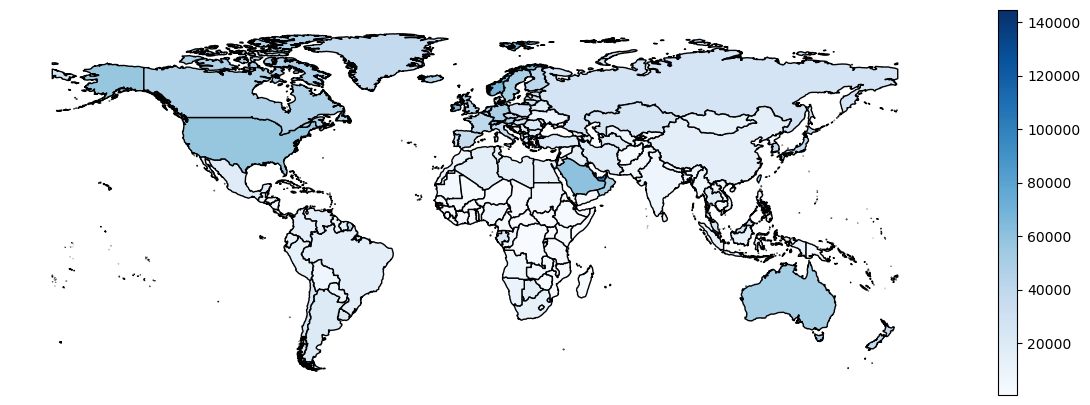

In [10]:
fig, gax = plt.subplots(figsize=(15,5))

world[world['POP_EST']>50000].plot(ax = gax, column='gdp_cap', edgecolor='black', cmap = 'Blues', legend=True)
# What happens if we don't remove low-pop?
#world.plot(ax = gax, column='gdp_cap', edgecolor='black', cmap = 'Blues', legend=True)

plt.axis('off')

plt.show()

That legend is atrocious. Never trust the defaults. 

The legend is taking up the entire vertical span of the figure, which I sized at (15,10), even though the map does not. There are two ways to fix this. 

1. Shrink the vertical size. (15,5) starts to look pretty good. 

2. Add a separate legend to our plot. This will require digging into the guts of matplotlib. It's a good thing we are already experienced with matplotlib.  First, we add a separate axis to our plot. Then we will tell the geopandas plot command to add the legend to the new axis. \[This method works on other types of plots as well. It is sometimes useful for heat maps and creating insets.\]

Let's take a look at the second way. It will teach us a bit more about axes.

In [11]:
# import the make_axes_locatable method from matplotlib
from mpl_toolkits.axes_grid1 import make_axes_locatable

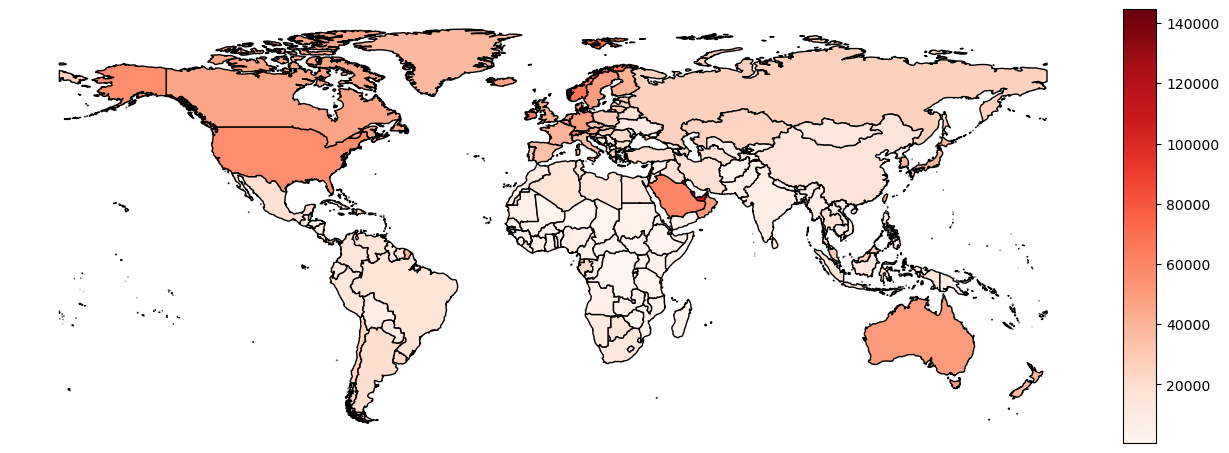

In [12]:
fig, map_ax = plt.subplots(figsize=(15,10))

# Adapted from https://geopandas.org/en/stable/docs/user_guide/mapping.html

# Create an axis divider object. It allows us to add another axis to the current one (map_ax).
divider = make_axes_locatable(map_ax)

# Add a second axis to the right of the original axes. 
# Make the new axes 3% of the original and add some padding between them.
legend_ax = divider.append_axes('right', size='3%', pad=0.1)

# The plot command works like normal, but: we plot the map on the map_ax (using the ax option)
# and we plot the legend on the legend_ax (using the cax option).
world[world['POP_EST']>50000].plot(
                                   ax = map_ax,                          # give ax the axes for the map
                                   column='gdp_cap',                     # the quantitative column
                                   edgecolor='black',                    # set the edge color
                                   cmap = 'Reds',                        # set the color map
                                   legend=True, cax=legend_ax )           # give cax the legend axes

# Here I ony turn off the axis of the main plot
map_ax.axis('off')

plt.show()

You can experiment with different padding, widths, locations, and color maps.

## Practice

At the end of the *maps* notebook, we created a map of Wisconsin's counties. We learned not only how to plot shape files, but where to find the shape files. 

Now let's color the map to reflect voting patterns in the 2024 presidential election. 

The steps:

1. Plot the county borders
3. Merge data on votes with geographical data
4. Color the map

We have already figured out the first step. The code below reproduces the map we finished with in the *maps* notebook. 

### 1. Plot the county borders

To read the data
```python
# Read in the counties shape file.
counties = geopandas.read_file('cb_2021_us_county_5m.zip')

# WI fips code is 55. Keep just the WI counties.
wi_counties = counties[counties['STATEFP']=='55'].copy()
wi_counties.head(2)
```

To make the plot
```python
fig, gax = plt.subplots(figsize=(10,10))
wi_counties.plot(ax=gax, edgecolor='black', color = 'white')
plt.axis('off')
plt.show()
```

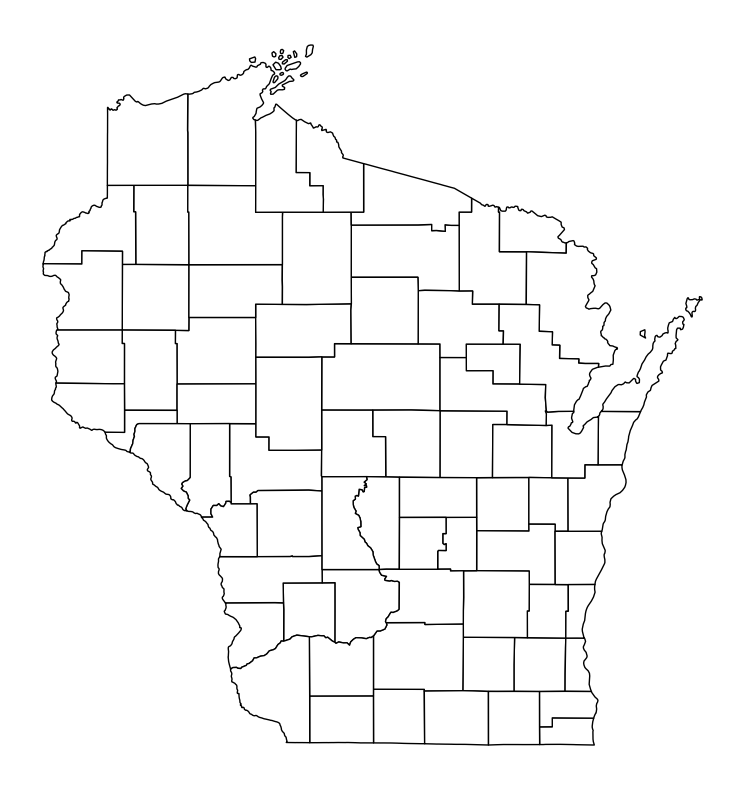

In [13]:
counties = gpd.read_file('data/cb_2021_us_all_5m/cb_2021_us_county_5m.zip')

wi_counties = counties[counties['STATEFP']=='55'].copy()
wi_counties.head(2)


fig, gax = plt.subplots(figsize=(10,10))
wi_counties.plot(ax=gax, edgecolor='black', color = 'white')
plt.axis('off')
plt.show()

### 2. Get the vote totals and merge them 

Time to add the voter totals. I found the data on the [Wisconsin Elections Commission website](https://elections.wi.gov/elections/election-results/results-all#accordion-868) and saved a cleaned-up version of the results to 'elections2024.csv' in Canvas. For fun, you could try locating the raw data on the website and wrangling it into shape. That's what you normally would have to do...and it's fun!

**2(a).**  Load 'elections2024.csv' to a DataFrame named `results`. Note, this is not a GeoDataFrame, so it doesn't have geometry; it just has county names and vote counts.

**Check your dtypes!** You may have to convert strings to ints.

In [14]:
results = pd.read_csv('data/elections2024.csv')
results.dtypes

county    object
total     object
harris    object
trump     object
dtype: object

In [15]:
results.sample(5)

,county,total,harris,trump
48,POLK,"28,222","9,567","18,296"
4,BROWN,"149,333","67,937","79,132"
26,JACKSON,"10,502","4,157","6,204"
41,MONROE,"23,369","8,476","14,563"
22,GREEN,"22,076","10,903","10,843"


In [16]:
for col in ['total', 'trump', 'harris']:
    results[col] = results[col].str.replace(',','')
    results[col] = results[col].astype(int)

results.dtypes

county    object
total      int64
harris     int64
trump      int64
dtype: object

In [17]:
results.sample(5)

,county,total,harris,trump
27,JEFFERSON,50146,20574,28771
40,MILWAUKEE,464107,316292,138022
71,WOOD,42216,16599,24997
29,KENOSHA,90680,41826,47478
47,PIERCE,25392,10171,14417


We need to standardize the county names to that we can merge the vote totals with the county shapefile. Let's make the county names 'title case'. We should also remove any extra whitespace. We know how to fix this. 

**2(b).** Convert the county names in `results` to title case. Strip any leading/trailing whitespace in the county names.

In [18]:
results['county'] = results['county'].str.strip()
results['county'] = results['county'].str.title()
results

,county,total,harris,trump
0,Adams,12882,4443,7763
1,Ashland,8955,4612,4191
2,Barron,26809,8941,16726
3,Bayfield,11240,6107,4860
4,Brown,149333,67937,79132
...,...,...,...,...
67,Waukesha,275787,108478,162768
68,Waupaca,30403,9947,20093
69,Waushara,14363,4571,9625
70,Winnebago,95371,44660,49179


**2(c).** Convert the county names in `wi_counties` to title case. Strip any leading/trailing whitespace in the county names.

In [19]:
wi_counties['NAME'] = wi_counties['NAME'].str.strip()
wi_counties['NAME'] = wi_counties['NAME'].str.title()
wi_counties

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
21,55,139,01581129,0500000US55139,55139,Winnebago,Winnebago County,WI,Wisconsin,06,1125859770,372631716,"POLYGON ((-88.887 44.243, -88.766 44.243, -88...."
48,55,017,01581068,0500000US55017,55017,Chippewa,Chippewa County,WI,Wisconsin,06,2611628507,85233303,"POLYGON ((-91.666 45.208, -91.542 45.207, -91...."
73,55,005,01581062,0500000US55005,55005,Barron,Barron County,WI,Wisconsin,06,2235281410,69194516,"POLYGON ((-92.155 45.64, -92.031 45.64, -91.54..."
114,55,041,01581080,0500000US55041,55041,Forest,Forest County,WI,Wisconsin,06,2626936100,83536591,"POLYGON ((-89.048 45.982, -88.933 45.982, -88...."
129,55,073,01581096,0500000US55073,55073,Marathon,Marathon County,WI,Wisconsin,06,4002035761,80651079,"POLYGON ((-90.315 45.034, -90.198 45.034, -90...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2719,55,063,01581091,0500000US55063,55063,La Crosse,La Crosse County,WI,Wisconsin,06,1170175008,73150469,"POLYGON ((-91.425 43.984, -91.322 43.984, -91...."
2937,55,127,01581123,0500000US55127,55127,Walworth,Walworth County,WI,Wisconsin,06,1438448435,54928965,"POLYGON ((-88.777 42.843, -88.772 42.843, -88...."
2960,55,083,01581102,0500000US55083,55083,Oconto,Oconto County,WI,Wisconsin,06,2583464370,392038653,"POLYGON ((-88.678 45.379, -88.428 45.377, -88...."
3176,55,019,01581069,0500000US55019,55019,Clark,Clark County,WI,Wisconsin,06,3133102168,23238832,"POLYGON ((-90.923 45.031, -90.434 45.031, -90...."


**2(d).** Merge `wi_counties` and `results`. Use the indicator option in the merge, and check that everything matched up using `.value_counts()`. There are 72 counties in Wisconsin.

In [21]:
res_w_states = pd.merge(left = wi_counties, right = results, left_on = 'NAME', right_on = 'county', how = 'outer', indicator=True)
res_w_states

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry,county,total,harris,trump,_merge
0,55,001,01581060,0500000US55001,55001,Adams,Adams County,WI,Wisconsin,06,1672216054,108348982,"POLYGON ((-90.026 44.092, -90.005 44.103, -90....",Adams,12882,4443,7763,both
1,55,003,01581061,0500000US55003,55003,Ashland,Ashland County,WI,Wisconsin,06,2706458787,3230728318,"MULTIPOLYGON (((-90.457 47.017, -90.457 47.044...",Ashland,8955,4612,4191,both
2,55,005,01581062,0500000US55005,55005,Barron,Barron County,WI,Wisconsin,06,2235281410,69194516,"POLYGON ((-92.155 45.64, -92.031 45.64, -91.54...",Barron,26809,8941,16726,both
3,55,007,01581063,0500000US55007,55007,Bayfield,Bayfield County,WI,Wisconsin,06,3827681907,1460296066,"MULTIPOLYGON (((-90.982 46.986, -90.933 46.998...",Bayfield,11240,6107,4860,both
4,55,009,01581064,0500000US55009,55009,Brown,Brown County,WI,Wisconsin,06,1372931376,221810753,"POLYGON ((-88.253 44.68, -88.243 44.68, -88.23...",Brown,149333,67937,79132,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,55,133,01581126,0500000US55133,55133,Waukesha,Waukesha County,WI,Wisconsin,06,1423769973,79817326,"POLYGON ((-88.542 43.019, -88.536 43.196, -88....",Waukesha,275787,108478,162768,both
68,55,135,01581127,0500000US55135,55135,Waupaca,Waupaca County,WI,Wisconsin,06,1936521055,45270535,"POLYGON ((-89.224 44.681, -88.605 44.678, -88....",Waupaca,30403,9947,20093,both
69,55,137,01581128,0500000US55137,55137,Waushara,Waushara County,WI,Wisconsin,06,1621749913,29096948,"POLYGON ((-89.598 44.246, -89.225 44.243, -88....",Waushara,14363,4571,9625,both
70,55,139,01581129,0500000US55139,55139,Winnebago,Winnebago County,WI,Wisconsin,06,1125859770,372631716,"POLYGON ((-88.887 44.243, -88.766 44.243, -88....",Winnebago,95371,44660,49179,both


In [22]:
res_w_states['_merge'].value_counts()

_merge
both          72
left_only      0
right_only     0
Name: count, dtype: int64

In [25]:
res_w_states['trump_share'] = res_w_states['trump']/res_w_states['total']

res_w_states

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry,county,total,harris,trump,_merge,trump_share
0,55,001,01581060,0500000US55001,55001,Adams,Adams County,WI,Wisconsin,06,1672216054,108348982,"POLYGON ((-90.026 44.092, -90.005 44.103, -90....",Adams,12882,4443,7763,both,0.602624
1,55,003,01581061,0500000US55003,55003,Ashland,Ashland County,WI,Wisconsin,06,2706458787,3230728318,"MULTIPOLYGON (((-90.457 47.017, -90.457 47.044...",Ashland,8955,4612,4191,both,0.468007
2,55,005,01581062,0500000US55005,55005,Barron,Barron County,WI,Wisconsin,06,2235281410,69194516,"POLYGON ((-92.155 45.64, -92.031 45.64, -91.54...",Barron,26809,8941,16726,both,0.623895
3,55,007,01581063,0500000US55007,55007,Bayfield,Bayfield County,WI,Wisconsin,06,3827681907,1460296066,"MULTIPOLYGON (((-90.982 46.986, -90.933 46.998...",Bayfield,11240,6107,4860,both,0.432384
4,55,009,01581064,0500000US55009,55009,Brown,Brown County,WI,Wisconsin,06,1372931376,221810753,"POLYGON ((-88.253 44.68, -88.243 44.68, -88.23...",Brown,149333,67937,79132,both,0.529903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,55,133,01581126,0500000US55133,55133,Waukesha,Waukesha County,WI,Wisconsin,06,1423769973,79817326,"POLYGON ((-88.542 43.019, -88.536 43.196, -88....",Waukesha,275787,108478,162768,both,0.590195
68,55,135,01581127,0500000US55135,55135,Waupaca,Waupaca County,WI,Wisconsin,06,1936521055,45270535,"POLYGON ((-89.224 44.681, -88.605 44.678, -88....",Waupaca,30403,9947,20093,both,0.660889
69,55,137,01581128,0500000US55137,55137,Waushara,Waushara County,WI,Wisconsin,06,1621749913,29096948,"POLYGON ((-89.598 44.246, -89.225 44.243, -88....",Waushara,14363,4571,9625,both,0.670125
70,55,139,01581129,0500000US55139,55139,Winnebago,Winnebago County,WI,Wisconsin,06,1125859770,372631716,"POLYGON ((-88.887 44.243, -88.766 44.243, -88....",Winnebago,95371,44660,49179,both,0.515660


**2(e).** Create a variable called 'trump_share' that is the share of trump votes out of the total vote count.

### 3. Color the map

Create a chloropeth map with colors that correspond to Trump's share of the vote. 

Remember the extra arguments.

1. `column` is set to the column name of the data we want to be 'colored'
2. `cmap` determines the color scheme. Try 'Reds' or 'bwr' or 'seismic'.
3. `legend` turn on the legend

If you use a *diverging color map*, like 'bwr,' you might want to specify the [min and max values](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html) for the legend. (Why?) 

4. Try changing the edge color of the counties to white. 
5. Add a title to your legend. Use the ` legend_kwds={'label': 'Legend title text'}` option of the plot command. ([docs](https://geopandas.org/en/stable/docs/user_guide/mapping.html#creating-a-legend)).

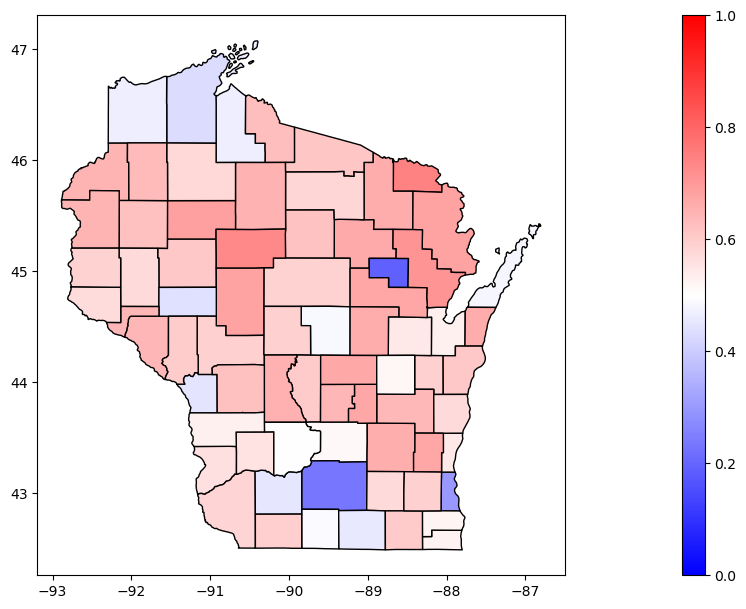

In [33]:
fig, ax = plt.subplots(figsize=(10,10))
divider = make_axes_locatable(ax)
legend_ax = divider.append_axes('right', size='3%', pad=0.1)
res_w_states.plot(ax = ax,
                   column='trump_share',
                    edgecolor='black',
                    cmap = 'bwr',
                    legend=True,
                    cax=legend_ax,
                    vmin=0,
                    vmax=1)
legend_kwds={'label': 'Legend title text'}
plt.show()

## Finish early?

1. Use the 'cities_4269' file on the course website and add Kenosha, Green Bay, Madison, and Milwaukee to your map. Try a white color and a black outline for the circle. Experiment with different combinations of colors and edge colors. What works best?
2. Label the cities. 

In [34]:
cities = gpd.read_file('data/cities_4269/cities_4269.shp')
cities

,city,rank,state,growth_fro,population,geometry
0,West Allis,582.0,Wisconsin,-0.6,60697.0,POINT (-88.007 43.017)
1,Waukesha,475.0,Wisconsin,8.0,71016.0,POINT (-88.231 43.012)
2,Wausau,945.0,Wisconsin,1.7,39309.0,POINT (-89.63 44.959)
3,Fond du Lac,857.0,Wisconsin,1.7,42970.0,POINT (-88.447 43.773)
4,Brookfield,971.0,Wisconsin,-1.9,37999.0,POINT (-88.106 43.061)
5,Eau Claire,508.0,Wisconsin,8.7,67545.0,POINT (-91.498 44.811)
6,Greenfield,993.0,Wisconsin,4.8,37159.0,POINT (-88.013 42.961)
7,Kenosha,294.0,Wisconsin,9.5,99889.0,POINT (-87.821 42.585)
8,New Berlin,926.0,Wisconsin,3.6,39834.0,POINT (-88.108 42.976)
9,La Crosse,716.0,Wisconsin,-0.8,51522.0,POINT (-91.24 43.801)


## Even more!

The labels on the map on [CNN](https://www.cnn.com/election/2024/results/wisconsin/president) have a white "shadow" around them. It's not too hard to add this to our labels. This technique works for any matplotlib text (and other objects, too). See this documentation for [path effects](https://matplotlib.org/stable/users/explain/artists/patheffects_guide.html#path-effects-guide) if you are interested in learning more.

1. Start by importing the patheffects module from matplotlib. This gives us some more tools. 

```python
import matplotlib.patheffects as PathEffects
```

2. The patheffects option in `.annotate()` takes a list of values. Try this: 

```python
.annotate(label, xy=(x,y), xytext=(3,3), textcoords='offset points',  
          path_effects=[PathEffects.withStroke(linewidth=3, foreground='white')]
          )
```
Experiment with different line widths, colors...

In [40]:
import matplotlib.patheffects as PathEffects

In [38]:
wisc_cities = gpd.read_file('data/cities_4269/cities_4269.shp')
#wisc_cities = geopandas.read_file('cities_4269.zip')
wisc_cities.head(2)

,city,rank,state,growth_fro,population,geometry
0,West Allis,582.0,Wisconsin,-0.6,60697.0,POINT (-88.007 43.017)
1,Waukesha,475.0,Wisconsin,8.0,71016.0,POINT (-88.231 43.012)


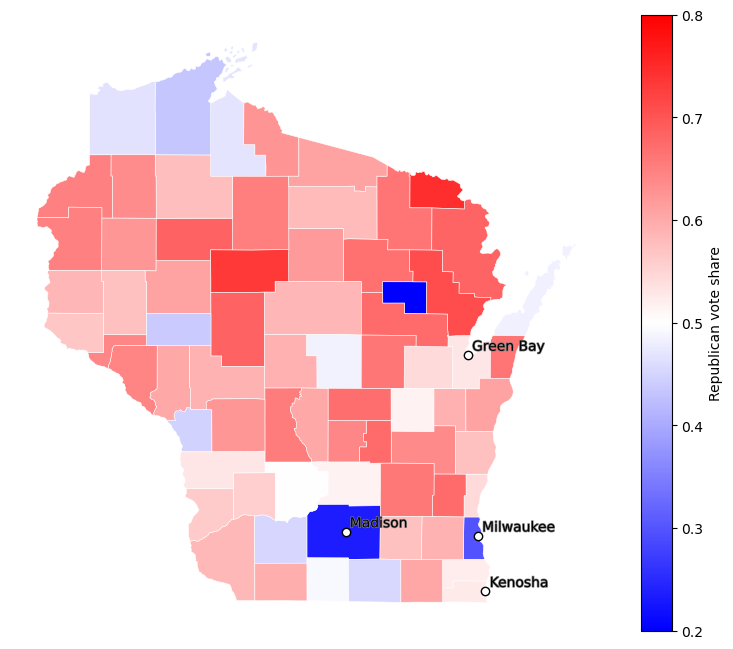

In [46]:
fig, gax = plt.subplots(figsize = (10,8))

# Plot the counties and pass 'trump_share' as the data to color
res_w_states.plot(ax=gax, edgecolor='white', linewidth=0.4, column='trump_share',  legend=True, cmap='bwr',
                  legend_kwds={'label':'Republican vote share'}, vmin=.2, vmax=.8)


cities_for_labels = wisc_cities[wisc_cities['city'].isin(['Madison', 'Green Bay', 'Milwaukee', 'Kenosha'])]

# Plot the points
cities_for_labels.plot(ax=gax, edgecolor='black', color='white')

# Label the points
for x, y, label in zip(cities_for_labels['geometry'].x, cities_for_labels['geometry'].y, cities_for_labels['city']):
    gax.annotate(label, xy=(x,y), xytext=(3,3), textcoords='offset points',  
                 path_effects=[PathEffects.withStroke(linewidth=1, foreground='grey')]
                 )

plt.axis('off')

plt.show()